# CSE438 Lab 12: Morphological Operations and Object Extraction

**Course:** CSE438 — Digital Image Processing  
**Dataset:** Betel Leaf Image Dataset from Bangladesh  
**Environment:** Kaggle Notebook  
**Instructor:** Dr. Md. Rifat Ahmmad Rashid

This lab demonstrates how binary morphology can be used to refine segmentation masks and extract objects from images.  
The Betel Leaf dataset is a **classification dataset**, not a pixel-level segmentation dataset. Therefore, this notebook first creates a foreground mask automatically and then uses that mask to demonstrate erosion, dilation, opening, closing, and connected-component analysis.

## Learning Objectives

After completing this lab, students should be able to:

1. apply erosion and dilation using different structuring elements;
2. use opening to remove small foreground noise;
3. use closing to fill small holes inside segmented objects;
4. extract foreground objects using morphological refinement;
5. label and count connected components from a binary image.

## Lab Tasks

1. Apply erosion with different structuring elements.  
2. Apply dilation with different structuring elements.  
3. Apply opening to remove small noise.  
4. Apply closing to fill holes.  
5. Label and count connected components.

In [1]:
# ============================================================
# Lab 12 Setup
# ============================================================

import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility for synthetic noise/hole demonstrations
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = False

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 4.13.0
NumPy version: 2.4.6


In [2]:
# ============================================================
# Dataset Path Configuration
# ============================================================
# Kaggle may mount the same dataset under slightly different paths.
# The code below checks common candidate paths and also searches
# /kaggle/input if needed.

CLASS_NAMES = [
    "Bacterial Leaf Disease",
    "Dried Leaf",
    "Fungal Brown Spot Disease",
    "Healthy Leaf",
]

CANDIDATE_ROOTS = [
    Path("/kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh"),
    Path("/kaggle/input/betel-leaf-image-dataset-from-bangladesh/data"),
    Path("/kaggle/input/betel-leaf-image-dataset"),
    Path("/mnt/data/betel-leaf-image-dataset-from-bangladesh"),
]

def looks_like_dataset_root(root: Path) -> bool:
    train_dir = root / "train"
    test_dir = root / "test"
    return (
        train_dir.exists()
        and test_dir.exists()
        and all((train_dir / cls).exists() for cls in CLASS_NAMES)
        and all((test_dir / cls).exists() for cls in CLASS_NAMES)
    )

def find_dataset_root() -> Path:
    for root in CANDIDATE_ROOTS:
        if looks_like_dataset_root(root):
            return root

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for root in kaggle_input.rglob("*"):
            if root.is_dir() and looks_like_dataset_root(root):
                return root

    raise FileNotFoundError(
        "Dataset root was not found. Add the Kaggle dataset to the notebook and check that "
        "the train/test folders contain the four expected class folders."
    )

DATASET_ROOT = find_dataset_root()
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUT_DIR = WORK_DIR / "cse438_lab12_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)
print("Output directory:", OUT_DIR)

Dataset root: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh
Train directory: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train
Test directory: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/test
Output directory: /kaggle/working/cse438_lab12_outputs


In [3]:
# ============================================================
# Dataset Summary
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def list_image_files(folder: Path):
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

summary_rows = []
for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for cls in CLASS_NAMES:
        files = list_image_files(split_dir / cls)
        summary_rows.append({
            "split": split_name,
            "class": cls,
            "image_count": len(files)
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("Total images:", int(summary_df["image_count"].sum()))

,split,class,image_count
0,train,Bacterial Leaf Disease,609
1,train,Dried Leaf,597
2,train,Fungal Brown Spot Disease,588
3,train,Healthy Leaf,594
4,test,Bacterial Leaf Disease,47
5,test,Dried Leaf,51
6,test,Fungal Brown Spot Disease,54
7,test,Healthy Leaf,49


Total images: 2589


In [4]:
# ============================================================
# Utility Functions
# ============================================================

def read_rgb(path: Path, target_size=(512, 512)):
    """
    Read an image using OpenCV, convert BGR to RGB, and resize it.
    """
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if target_size is not None:
        rgb = cv2.resize(rgb, target_size, interpolation=cv2.INTER_AREA)
    return rgb

def to_gray(rgb):
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def show_images(images, titles=None, cmap=None, cols=3, figsize=(14, 8)):
    """
    Display a list of images in a grid.
    """
    n = len(images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)
    for i, img in enumerate(images, 1):
        plt.subplot(rows, cols, i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap or "gray", vmin=0, vmax=255)
        else:
            plt.imshow(img)
        if titles:
            plt.title(titles[i - 1])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def save_gray_image(name, image):
    path = OUT_DIR / name
    cv2.imwrite(str(path), image)
    return path

def save_rgb_image(name, image):
    path = OUT_DIR / name
    bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), bgr)
    return path

def ensure_binary(mask):
    """
    Convert any mask to binary uint8 values {0, 255}.
    """
    return ((mask > 0).astype(np.uint8) * 255)

def count_components(mask, connectivity=8):
    """
    Count foreground connected components, excluding the background.
    """
    binary = ensure_binary(mask)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=connectivity)
    return num_labels - 1, labels, stats, centroids

## 1. Select a Representative Betel Leaf Image

The selected image is used throughout this lab. Students may change `SELECTED_CLASS` to observe how morphology behaves on different visual conditions.

Selected image: /kaggle/input/datasets/rifat963/betel-leaf-image-dataset-from-bangladesh/train/Healthy Leaf/Healthy_Leaf-1-_jpg.rf.2bbab1284996789ca5375cbca7337959.jpg
Image shape: (512, 512, 3)
Grayscale shape: (512, 512)


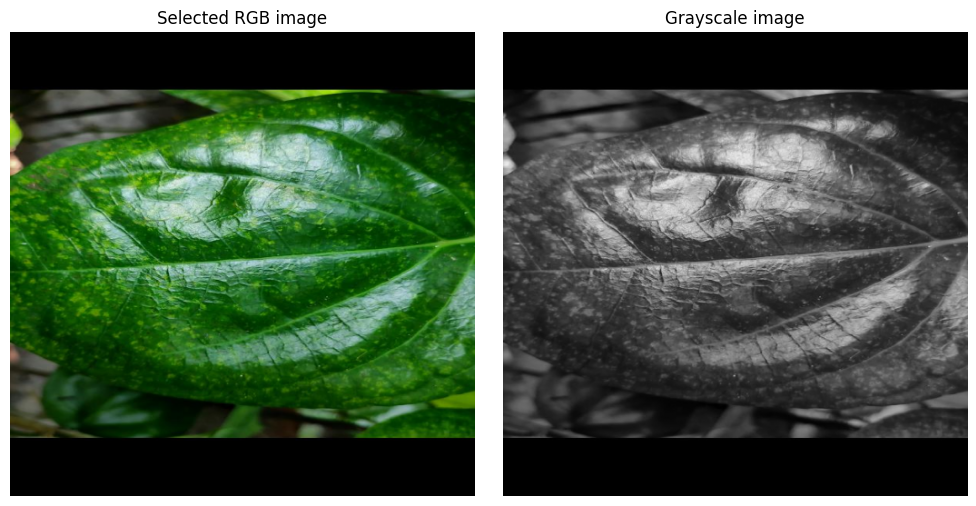

In [5]:
# ============================================================
# Select an Image for Morphological Processing
# ============================================================

SELECTED_CLASS = "Healthy Leaf"   # Try: "Bacterial Leaf Disease", "Dried Leaf", "Fungal Brown Spot Disease", "Healthy Leaf"
selected_files = list_image_files(TRAIN_DIR / SELECTED_CLASS)

if len(selected_files) == 0:
    raise FileNotFoundError(f"No images found for class: {SELECTED_CLASS}")

image_path = selected_files[0]
rgb = read_rgb(image_path, target_size=(512, 512))
gray = to_gray(rgb)

print("Selected image:", image_path)
print("Image shape:", rgb.shape)
print("Grayscale shape:", gray.shape)

show_images(
    [rgb, gray],
    ["Selected RGB image", "Grayscale image"],
    cols=2,
    figsize=(10, 5)
)

## 2. Create a Binary Foreground Mask

Morphological operations are usually applied to binary masks. Since this dataset does not provide manual masks, this section creates a working foreground mask using grayscale thresholding and connected-component selection.

The goal here is not to claim a perfect segmentation mask. The goal is to create a reasonable binary image for studying morphological behavior.

Otsu threshold value: 71.0
Base foreground ratio: 0.3218


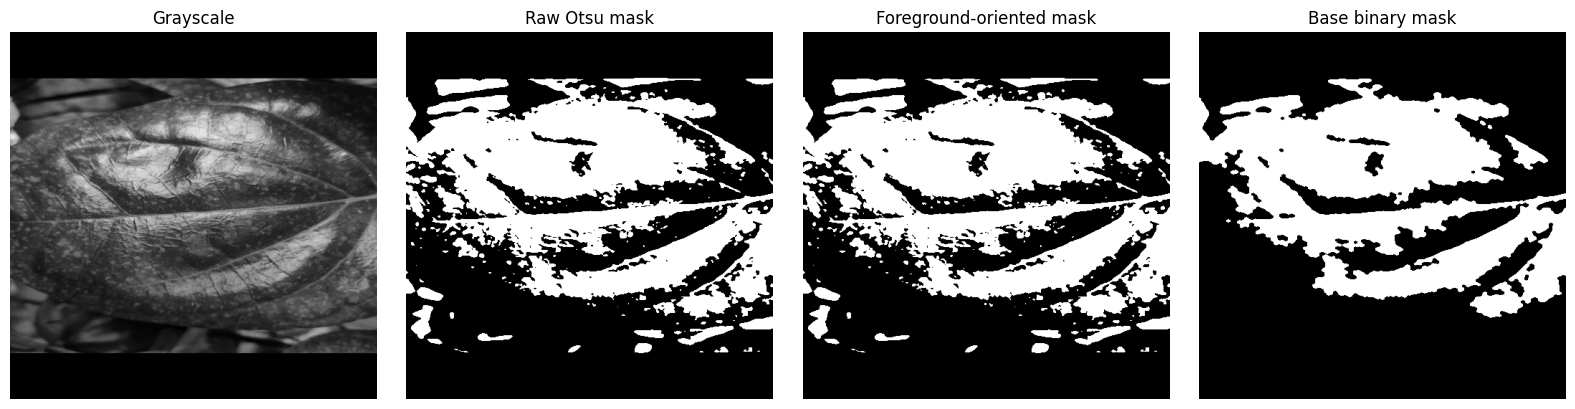

PosixPath('/kaggle/working/cse438_lab12_outputs/01_base_binary_mask.png')

In [6]:
# ============================================================
# Binary Mask Generation
# ============================================================

def largest_component_mask(binary_mask):
    """
    Keep only the largest foreground connected component.
    This is useful when thresholding produces several scattered regions.
    """
    binary_mask = ensure_binary(binary_mask)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    if num_labels <= 1:
        return binary_mask

    # Background label is 0. Foreground labels start from 1.
    foreground_areas = stats[1:, cv2.CC_STAT_AREA]
    largest_label = 1 + int(np.argmax(foreground_areas))
    largest = np.where(labels == largest_label, 255, 0).astype(np.uint8)
    return largest

def choose_foreground_orientation(binary_mask):
    """
    Otsu thresholding can make either the object or the background white.
    This function compares both orientations and chooses the one with a
    plausible foreground area and compact central object.
    """
    candidates = [ensure_binary(binary_mask), ensure_binary(255 - binary_mask)]
    best_score = -np.inf
    best_mask = candidates[0]

    h, w = binary_mask.shape
    center_window = (slice(h // 4, 3 * h // 4), slice(w // 4, 3 * w // 4))

    for candidate in candidates:
        fg_ratio = np.mean(candidate > 0)
        largest = largest_component_mask(candidate)
        largest_ratio = np.mean(largest > 0)
        center_ratio = np.mean(largest[center_window] > 0)

        # Penalize extremely tiny or almost-full foreground masks.
        penalty = 0
        if fg_ratio < 0.03 or fg_ratio > 0.90:
            penalty = 1

        score = largest_ratio + 0.25 * center_ratio - penalty
        if score > best_score:
            best_score = score
            best_mask = candidate

    return best_mask

blurred = cv2.GaussianBlur(gray, (5, 5), 0)
otsu_value, otsu_binary = cv2.threshold(
    blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

foreground_mask = choose_foreground_orientation(otsu_binary)
foreground_largest = largest_component_mask(foreground_mask)

# A light morphological clean-up before using it as the base object mask
base_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
base_mask = cv2.morphologyEx(foreground_largest, cv2.MORPH_CLOSE, base_kernel, iterations=1)
base_mask = cv2.morphologyEx(base_mask, cv2.MORPH_OPEN, base_kernel, iterations=1)

print("Otsu threshold value:", otsu_value)
print("Base foreground ratio:", round(float(np.mean(base_mask > 0)), 4))

show_images(
    [gray, otsu_binary, foreground_mask, base_mask],
    ["Grayscale", "Raw Otsu mask", "Foreground-oriented mask", "Base binary mask"],
    cols=4,
    figsize=(16, 4)
)

save_gray_image("01_base_binary_mask.png", base_mask)

## 3. Structuring Elements

A structuring element defines the local neighborhood used by a morphological operator.  
This lab uses three common shapes: rectangular, elliptical, and cross-shaped kernels.

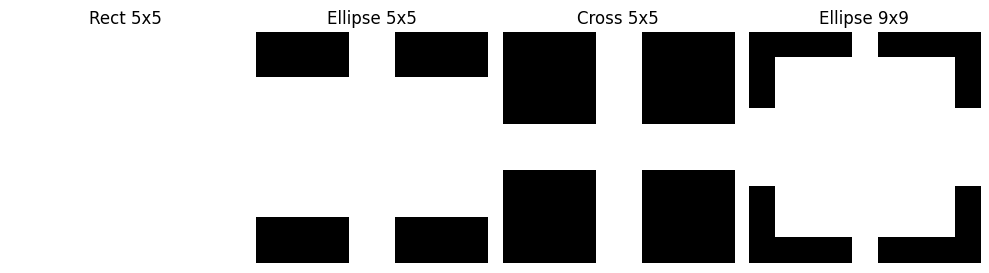


Rect 5x5:
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]

Ellipse 5x5:
[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]

Cross 5x5:
[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]

Ellipse 9x9:
[[0 0 0 0 1 0 0 0 0]
 [0 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 0]
 [0 0 0 0 1 0 0 0 0]]


In [7]:
# ============================================================
# Structuring Elements
# ============================================================

structuring_elements = {
    "Rect 5x5": cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    "Ellipse 5x5": cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),
    "Cross 5x5": cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5)),
    "Ellipse 9x9": cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)),
}

plt.figure(figsize=(10, 3))
for i, (name, kernel) in enumerate(structuring_elements.items(), 1):
    plt.subplot(1, len(structuring_elements), i)
    plt.imshow(kernel, cmap="gray", vmin=0, vmax=1)
    plt.title(name)
    plt.axis("off")
plt.tight_layout()
plt.show()

for name, kernel in structuring_elements.items():
    print(f"\n{name}:\n{kernel}")

## 4. Task 1 — Apply Erosion with Different Structuring Elements

Erosion removes boundary pixels from the foreground. It is useful for shrinking objects, breaking thin connections, and removing small foreground regions.

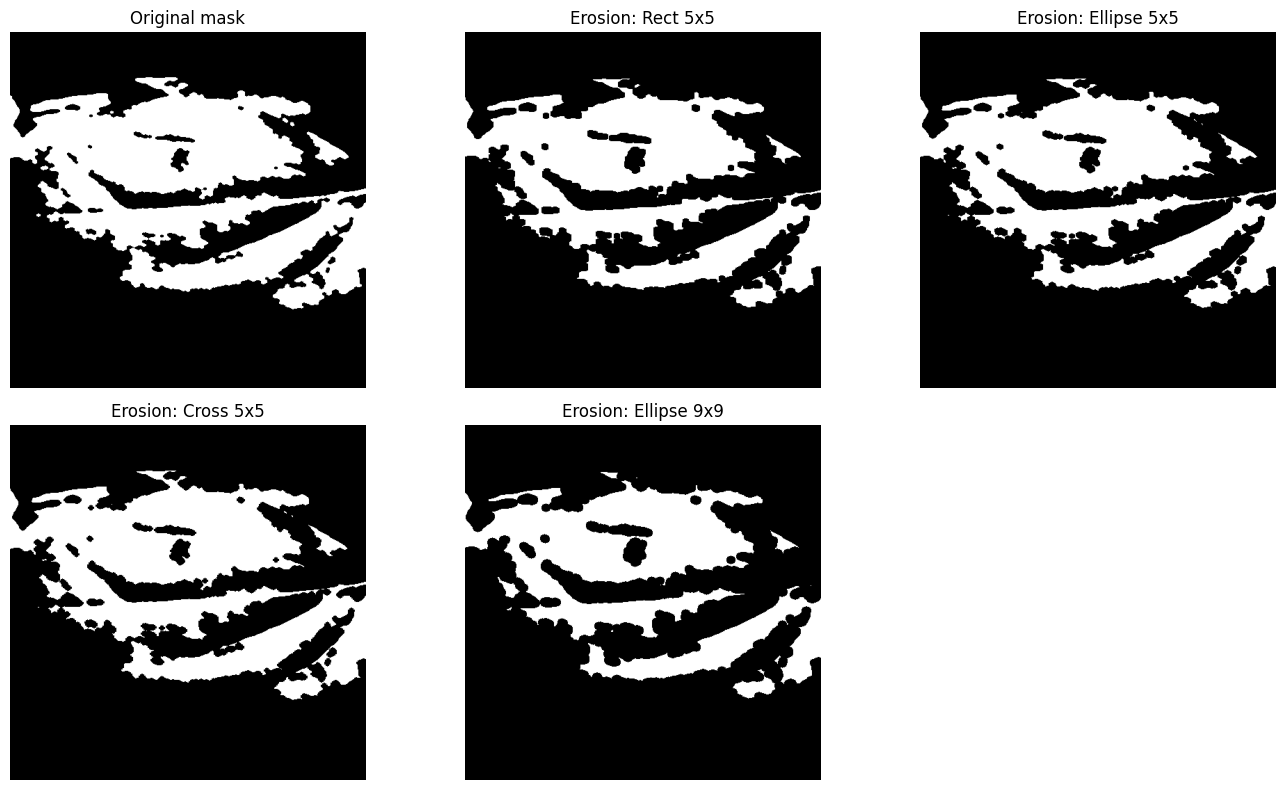

In [8]:
# ============================================================
# Erosion with Different Structuring Elements
# ============================================================

erosion_results = {}
for name, kernel in structuring_elements.items():
    erosion_results[name] = cv2.erode(base_mask, kernel, iterations=1)

show_images(
    [base_mask] + list(erosion_results.values()),
    ["Original mask"] + [f"Erosion: {name}" for name in erosion_results.keys()],
    cols=3,
    figsize=(14, 8)
)

for name, img in erosion_results.items():
    safe_name = name.replace(" ", "_").replace("/", "_")
    save_gray_image(f"02_erosion_{safe_name}.png", img)

## 5. Task 2 — Apply Dilation

Dilation expands foreground regions. It is useful for filling small gaps, joining nearby components, and recovering object boundaries after erosion.

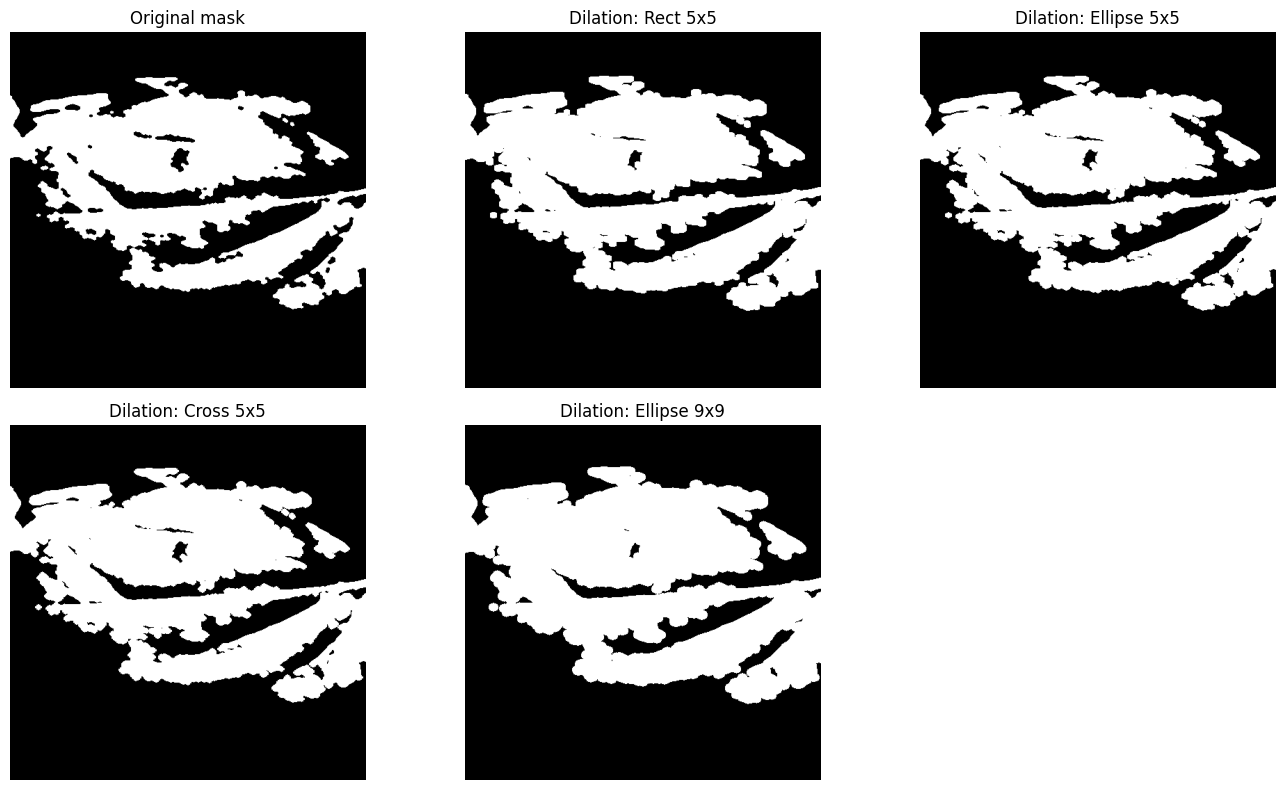

In [9]:
# ============================================================
# Dilation with Different Structuring Elements
# ============================================================

dilation_results = {}
for name, kernel in structuring_elements.items():
    dilation_results[name] = cv2.dilate(base_mask, kernel, iterations=1)

show_images(
    [base_mask] + list(dilation_results.values()),
    ["Original mask"] + [f"Dilation: {name}" for name in dilation_results.keys()],
    cols=3,
    figsize=(14, 8)
)

for name, img in dilation_results.items():
    safe_name = name.replace(" ", "_").replace("/", "_")
    save_gray_image(f"03_dilation_{safe_name}.png", img)

## 6. Task 3 — Apply Opening to Remove Small Noise

Opening is erosion followed by dilation. It removes small foreground noise while preserving the approximate size of larger objects.

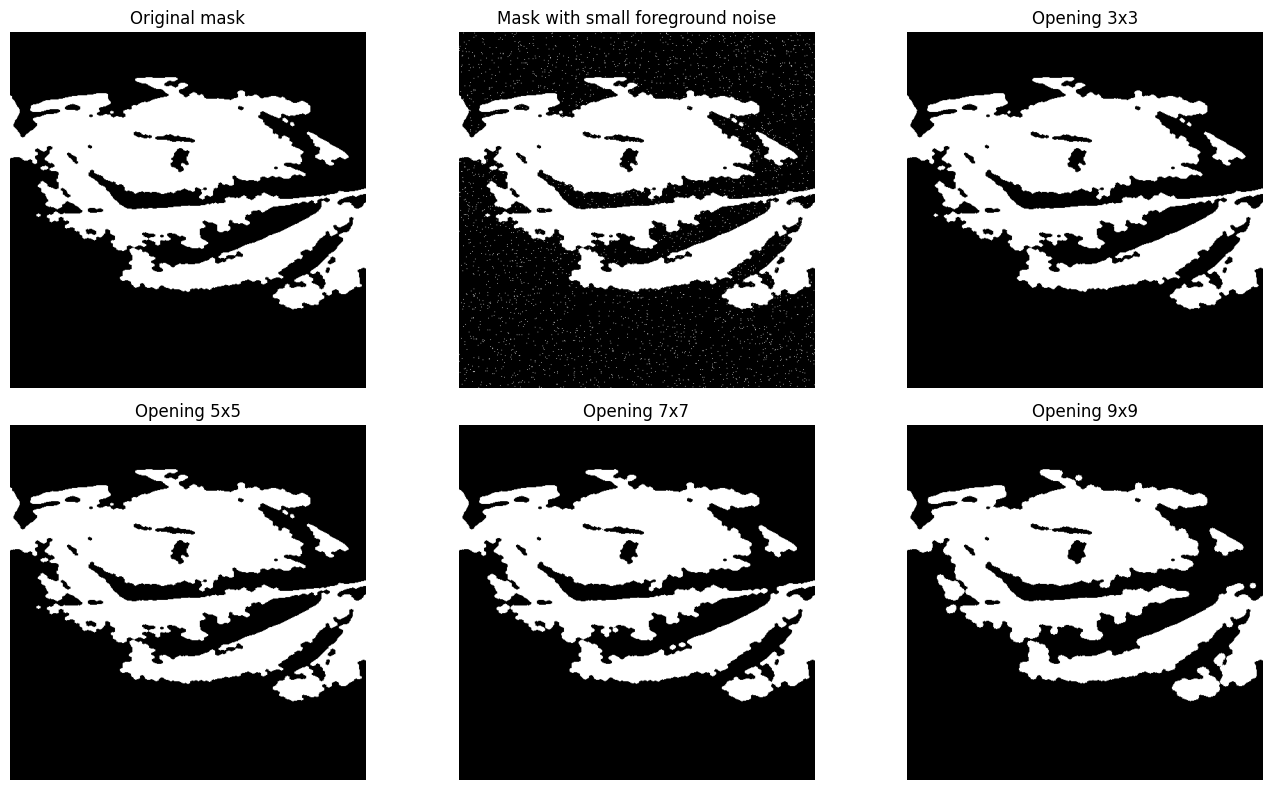

In [10]:
# ============================================================
# Opening for Small Noise Removal
# ============================================================

def add_foreground_speckle_noise(mask, probability=0.015):
    """
    Add small white speckles to the background to demonstrate opening.
    """
    noisy = mask.copy()
    noise = rng.random(mask.shape) < probability
    noisy[noise] = 255
    return noisy

noisy_foreground_mask = add_foreground_speckle_noise(base_mask, probability=0.015)

opening_kernel_sizes = [3, 5, 7, 9]
opening_results = {}

for k in opening_kernel_sizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    opening_results[f"Opening {k}x{k}"] = cv2.morphologyEx(
        noisy_foreground_mask, cv2.MORPH_OPEN, kernel, iterations=1
    )

show_images(
    [base_mask, noisy_foreground_mask] + list(opening_results.values()),
    ["Original mask", "Mask with small foreground noise"] + list(opening_results.keys()),
    cols=3,
    figsize=(14, 8)
)

save_gray_image("04_noisy_foreground_mask.png", noisy_foreground_mask)
for name, img in opening_results.items():
    save_gray_image(f"05_{name.replace(' ', '_')}.png", img)

## 7. Task 4 — Apply Closing to Fill Holes

Closing is dilation followed by erosion. It fills small holes and narrow gaps inside foreground objects.

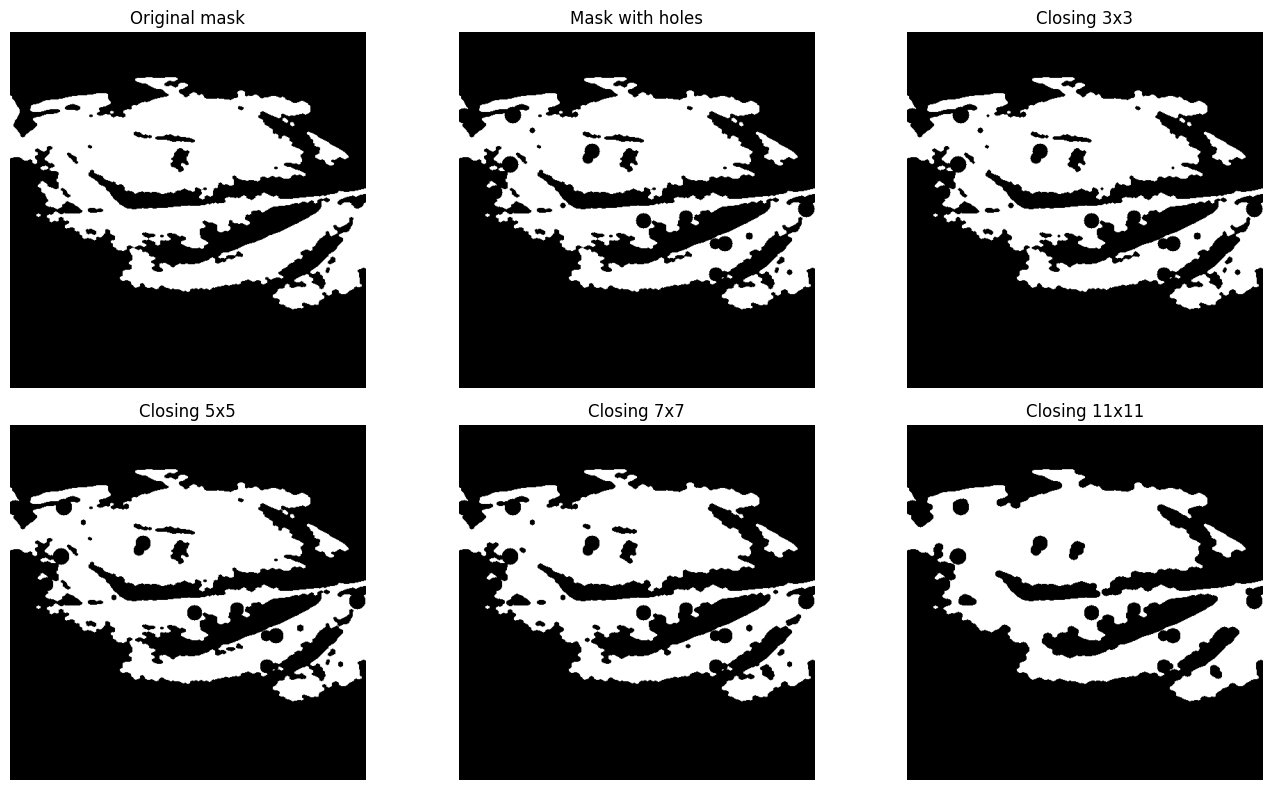

In [11]:
# ============================================================
# Closing for Hole Filling
# ============================================================

def add_holes_inside_mask(mask, number_of_holes=18, min_radius=4, max_radius=12):
    """
    Create small black holes inside the foreground mask to demonstrate closing.
    """
    mask_with_holes = mask.copy()
    ys, xs = np.where(mask_with_holes > 0)

    if len(xs) == 0:
        return mask_with_holes

    chosen = rng.choice(len(xs), size=min(number_of_holes, len(xs)), replace=False)

    for idx in chosen:
        center = (int(xs[idx]), int(ys[idx]))
        radius = int(rng.integers(min_radius, max_radius + 1))
        cv2.circle(mask_with_holes, center, radius, 0, -1)

    return mask_with_holes

hole_mask = add_holes_inside_mask(base_mask)

closing_kernel_sizes = [3, 5, 7, 11]
closing_results = {}

for k in closing_kernel_sizes:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    closing_results[f"Closing {k}x{k}"] = cv2.morphologyEx(
        hole_mask, cv2.MORPH_CLOSE, kernel, iterations=1
    )

show_images(
    [base_mask, hole_mask] + list(closing_results.values()),
    ["Original mask", "Mask with holes"] + list(closing_results.keys()),
    cols=3,
    figsize=(14, 8)
)

save_gray_image("06_mask_with_holes.png", hole_mask)
for name, img in closing_results.items():
    save_gray_image(f"07_{name.replace(' ', '_')}.png", img)

## 8. Morphological Object Extraction Pipeline

A common object-extraction workflow is:

1. create a binary foreground mask;
2. remove small noise using opening;
3. fill small holes using closing;
4. keep connected foreground regions;
5. label and measure components.

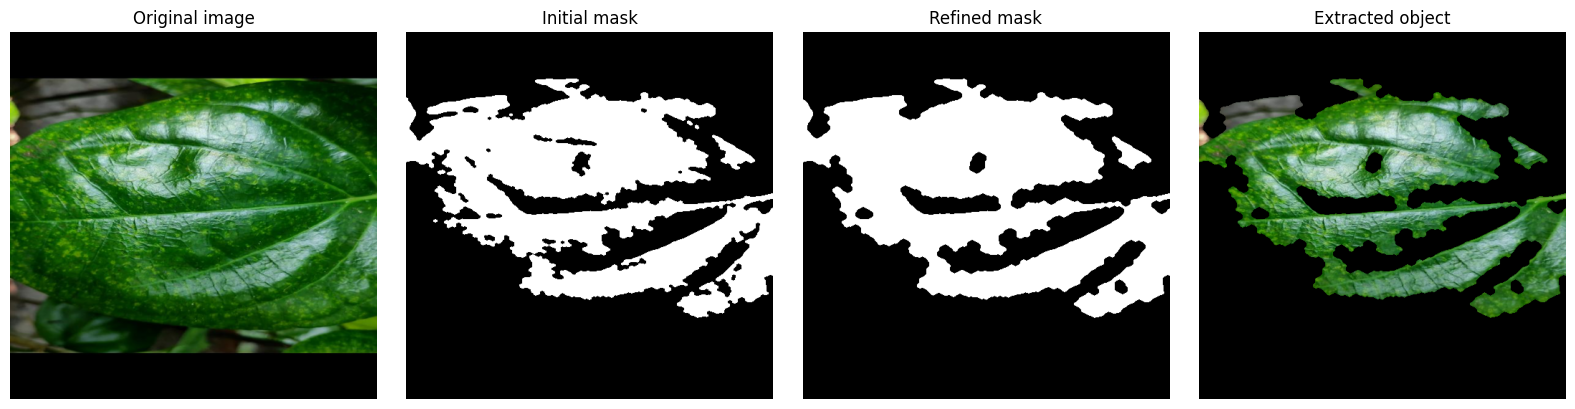

PosixPath('/kaggle/working/cse438_lab12_outputs/09_extracted_object.png')

In [12]:
# ============================================================
# Complete Morphological Refinement Pipeline
# ============================================================

pipeline_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

refined_mask = cv2.morphologyEx(base_mask, cv2.MORPH_OPEN, pipeline_kernel, iterations=1)
refined_mask = cv2.morphologyEx(refined_mask, cv2.MORPH_CLOSE, pipeline_kernel, iterations=2)

# Extract the object region from the RGB image
object_extracted = rgb.copy()
object_extracted[refined_mask == 0] = 0

show_images(
    [rgb, base_mask, refined_mask, object_extracted],
    ["Original image", "Initial mask", "Refined mask", "Extracted object"],
    cols=4,
    figsize=(16, 4)
)

save_gray_image("08_refined_morphological_mask.png", refined_mask)
save_rgb_image("09_extracted_object.png", object_extracted)

## 9. Task 5 — Label and Count Connected Components

Connected-component analysis assigns a unique label to each foreground object.  
This is useful for object counting, area measurement, bounding-box extraction, and object-level analysis.

In [13]:
# ============================================================
# Connected-Component Labeling and Counting
# ============================================================

def component_table(mask, min_area=100):
    """
    Return a DataFrame containing component measurements.
    """
    binary = ensure_binary(mask)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    rows = []
    for label_id in range(1, num_labels):  # Exclude background label 0
        x = int(stats[label_id, cv2.CC_STAT_LEFT])
        y = int(stats[label_id, cv2.CC_STAT_TOP])
        w = int(stats[label_id, cv2.CC_STAT_WIDTH])
        h = int(stats[label_id, cv2.CC_STAT_HEIGHT])
        area = int(stats[label_id, cv2.CC_STAT_AREA])
        cx, cy = centroids[label_id]

        if area >= min_area:
            rows.append({
                "label": label_id,
                "area_pixels": area,
                "bbox_x": x,
                "bbox_y": y,
                "bbox_width": w,
                "bbox_height": h,
                "centroid_x": round(float(cx), 2),
                "centroid_y": round(float(cy), 2),
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("area_pixels", ascending=False).reset_index(drop=True)
    return df, labels

components_df, label_image = component_table(refined_mask, min_area=100)

print("Number of connected components after area filtering:", len(components_df))
display(components_df)

components_df.to_csv(OUT_DIR / "10_connected_components_table.csv", index=False)

Number of connected components after area filtering: 2


,label,area_pixels,bbox_x,bbox_y,bbox_width,bbox_height,centroid_x,centroid_y
0,1,87258,0,65,512,334,256.92,221.17
1,2,1081,431,145,55,47,455.92,170.07


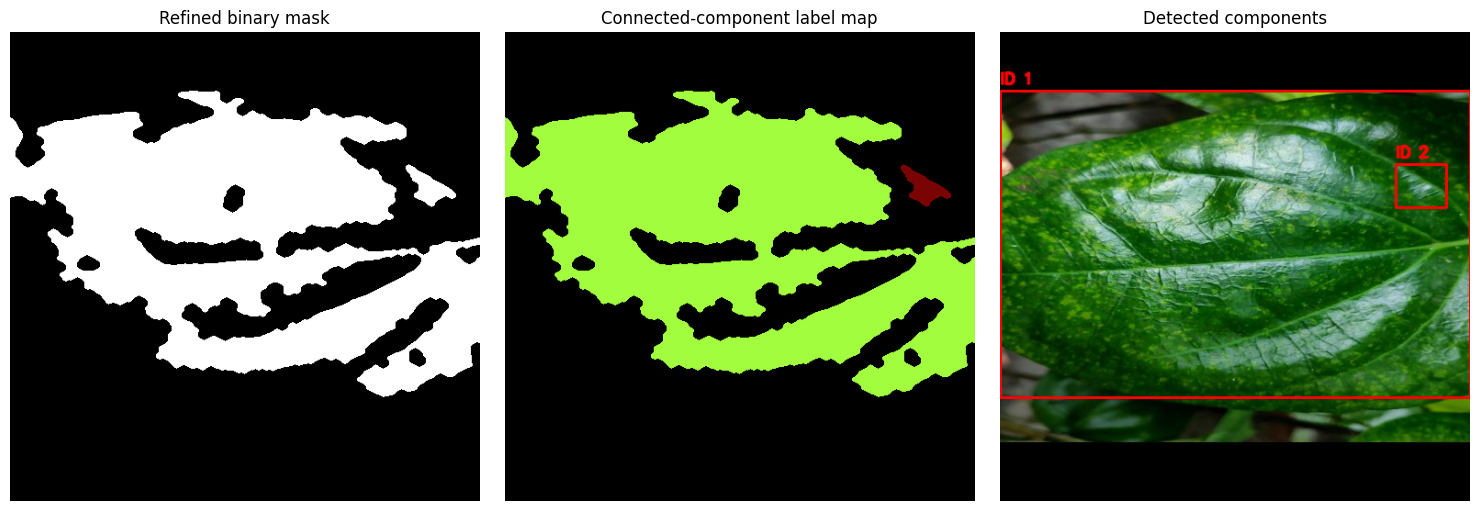

PosixPath('/kaggle/working/cse438_lab12_outputs/12_component_label_map.png')

In [14]:
# ============================================================
# Visualize Labeled Components
# ============================================================

def draw_component_boxes(rgb_image, components):
    """
    Draw bounding boxes and component IDs on an RGB image.
    """
    annotated = rgb_image.copy()

    for _, row in components.iterrows():
        x = int(row["bbox_x"])
        y = int(row["bbox_y"])
        w = int(row["bbox_width"])
        h = int(row["bbox_height"])
        label = int(row["label"])

        cv2.rectangle(annotated, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(
            annotated,
            f"ID {label}",
            (x, max(y - 8, 18)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 0, 0),
            2,
            cv2.LINE_AA,
        )

    return annotated

annotated_components = draw_component_boxes(rgb, components_df)

# Create a color label map for visualization
label_visual = np.zeros((*label_image.shape, 3), dtype=np.uint8)
if label_image.max() > 0:
    label_norm = (label_image.astype(np.float32) / label_image.max() * 255).astype(np.uint8)
    label_visual = cv2.applyColorMap(label_norm, cv2.COLORMAP_TURBO)
    label_visual[label_image == 0] = 0
    label_visual = cv2.cvtColor(label_visual, cv2.COLOR_BGR2RGB)

show_images(
    [refined_mask, label_visual, annotated_components],
    ["Refined binary mask", "Connected-component label map", "Detected components"],
    cols=3,
    figsize=(15, 5)
)

save_rgb_image("11_annotated_connected_components.png", annotated_components)
save_rgb_image("12_component_label_map.png", label_visual)

## 10. Compare Morphological Effects Quantitatively

The following table summarizes how each operation changes the number of components, foreground area, and foreground-area ratio.

In [15]:
# ============================================================
# Quantitative Morphology Summary
# ============================================================

def morphology_summary(name, mask):
    component_count, _, stats, _ = count_components(mask)
    foreground_pixels = int(np.sum(mask > 0))
    area_ratio = foreground_pixels / mask.size

    return {
        "image": name,
        "component_count": int(component_count),
        "foreground_pixels": foreground_pixels,
        "foreground_area_ratio": round(float(area_ratio), 4),
    }

summary_items = [
    ("Base mask", base_mask),
    ("Eroded: Ellipse 5x5", erosion_results["Ellipse 5x5"]),
    ("Dilated: Ellipse 5x5", dilation_results["Ellipse 5x5"]),
    ("Noisy foreground mask", noisy_foreground_mask),
    ("Opening 7x7", opening_results["Opening 7x7"]),
    ("Mask with holes", hole_mask),
    ("Closing 7x7", closing_results["Closing 7x7"]),
    ("Refined mask", refined_mask),
]

morphology_summary_df = pd.DataFrame([morphology_summary(name, mask) for name, mask in summary_items])
display(morphology_summary_df)

morphology_summary_df.to_csv(OUT_DIR / "13_morphology_summary.csv", index=False)

,image,component_count,foreground_pixels,foreground_area_ratio
0,Base mask,7,84345,0.3218
1,Eroded: Ellipse 5x5,18,72974,0.2784
2,Dilated: Ellipse 5x5,3,95408,0.3640
3,Noisy foreground mask,2405,87009,0.3319
4,Opening 7x7,5,83265,0.3176
5,Mask with holes,14,80423,0.3068
6,Closing 7x7,9,82197,0.3136
7,Refined mask,2,88339,0.3370


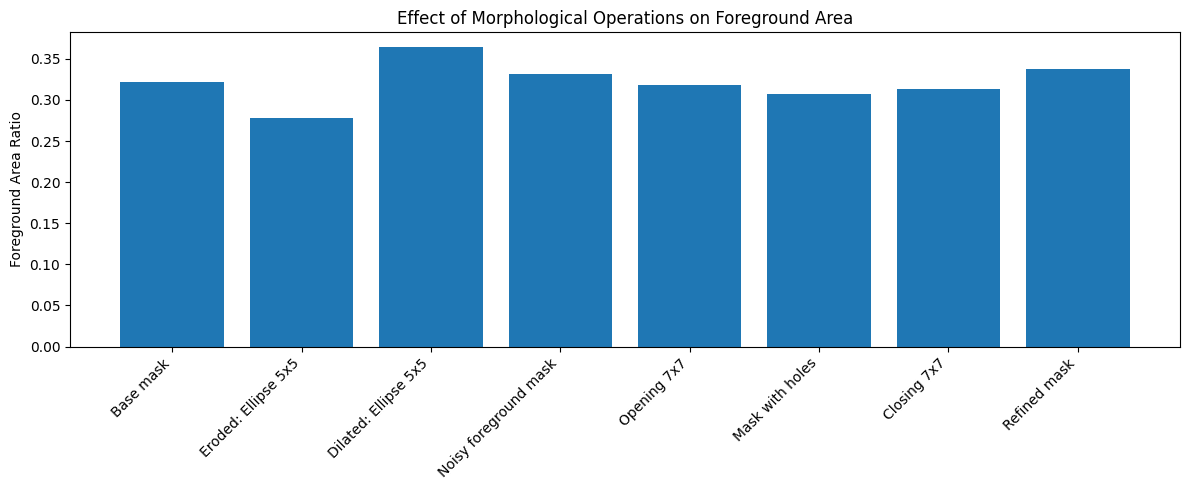

In [16]:
# ============================================================
# Plot Foreground Area Ratio
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(
    morphology_summary_df["image"],
    morphology_summary_df["foreground_area_ratio"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Foreground Area Ratio")
plt.title("Effect of Morphological Operations on Foreground Area")
plt.tight_layout()
plt.savefig(OUT_DIR / "14_foreground_area_ratio_plot.png", dpi=150)
plt.show()

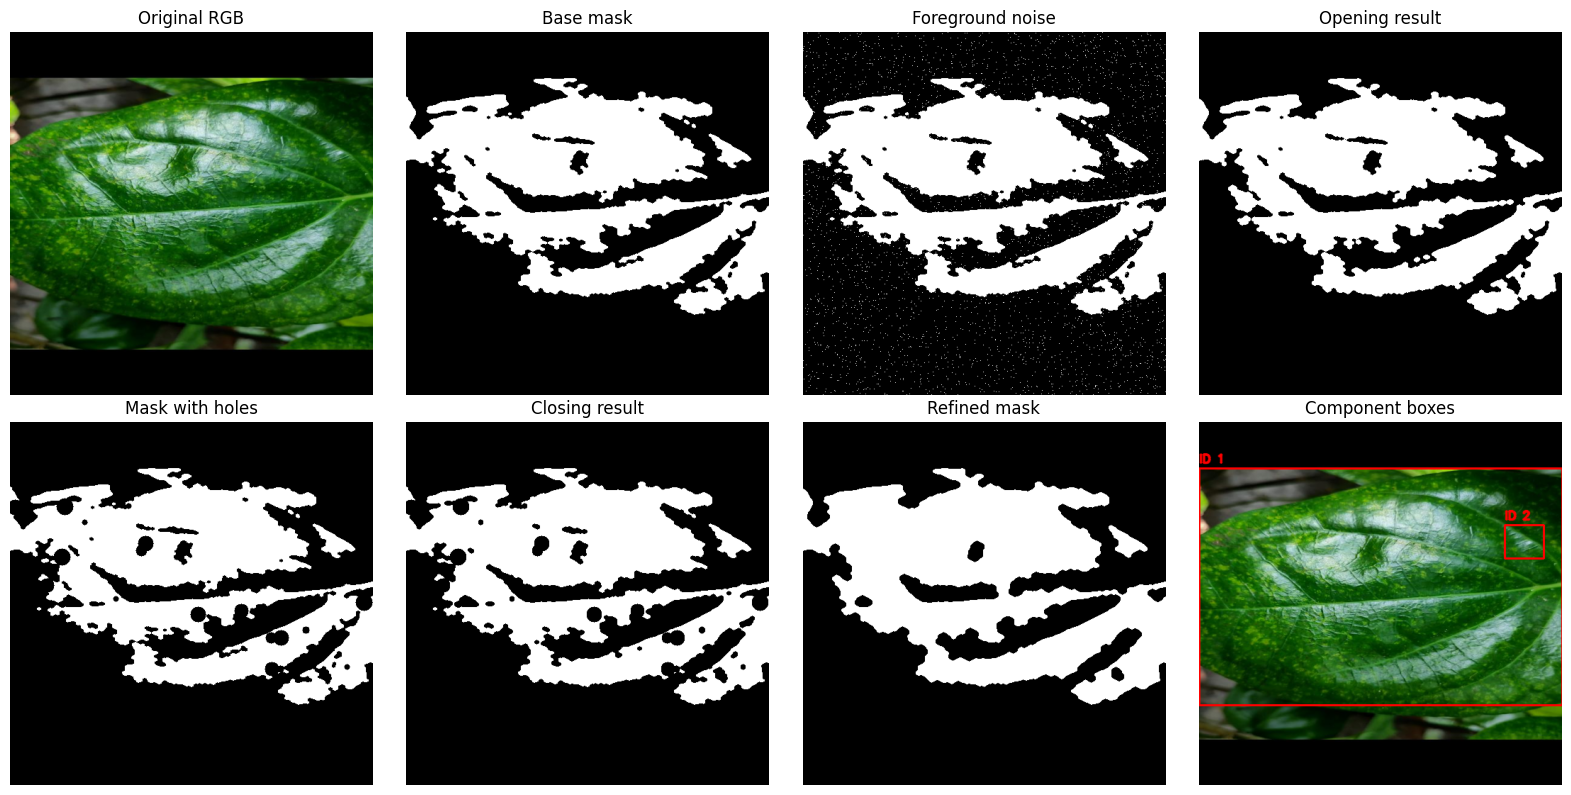

Saved outputs to: /kaggle/working/cse438_lab12_outputs


In [17]:
# ============================================================
# Save a Final Comparison Figure
# ============================================================

comparison_images = [
    rgb,
    base_mask,
    noisy_foreground_mask,
    opening_results["Opening 7x7"],
    hole_mask,
    closing_results["Closing 7x7"],
    refined_mask,
    annotated_components,
]

comparison_titles = [
    "Original RGB",
    "Base mask",
    "Foreground noise",
    "Opening result",
    "Mask with holes",
    "Closing result",
    "Refined mask",
    "Component boxes",
]

plt.figure(figsize=(16, 8))
for i, (img, title) in enumerate(zip(comparison_images, comparison_titles), 1):
    plt.subplot(2, 4, i)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "15_lab12_final_comparison.png", dpi=150)
plt.show()

print("Saved outputs to:", OUT_DIR)

In [18]:
# Summary:
# In this lab, we created a binary foreground mask from a Betel Leaf image and applied
# erosion, dilation, opening, and closing with different structuring elements.
# Opening reduced small foreground noise, closing filled small holes, and connected-component
# labeling was used to count and measure extracted objects. These operations form the
# practical basis for mask refinement and object extraction in digital image processing.